In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

df = pd.read_csv("matrix_result.txt")
# Compute derived metrics (assuming number of GPU cores = 256)
NUM_CORES = 256
df["EFFICIENCY"] = df["SPEEDUP"] / NUM_CORES
df["COST"] = df["PAR_MS"] * NUM_CORES
xticks = [0, 100, 200, 300, 400, 500]

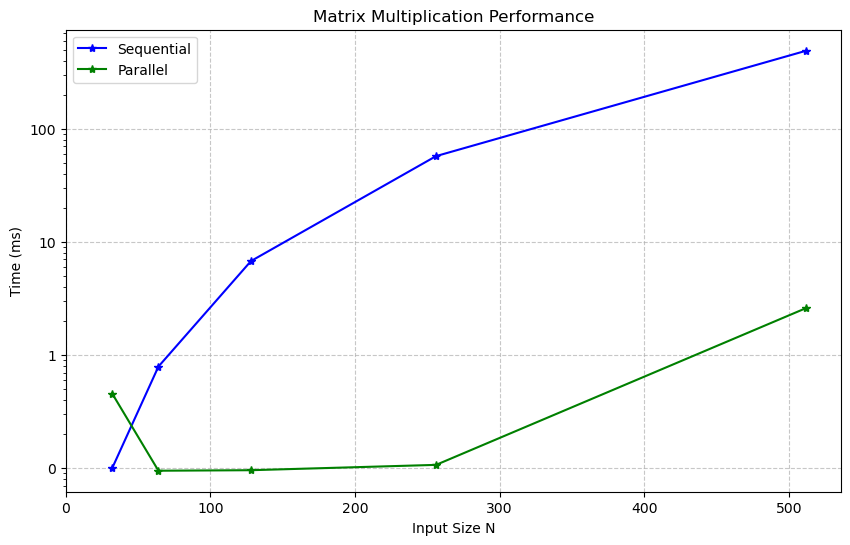

In [22]:
# ================= MATRIX MULT PERFORMANCE =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
seq = np.maximum(df["SEQ_MS"], 1e-4)
par = np.maximum(df["PAR_MS"], 1e-4)
plt.plot(df["N"], seq, 'b*-', label='Sequential')
plt.plot(df["N"], par, 'g*-', label='Parallel')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.xticks(xticks)
plt.xlabel("Input Size N")
plt.ylabel("Time (ms)")
plt.title("Matrix Multiplication Performance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

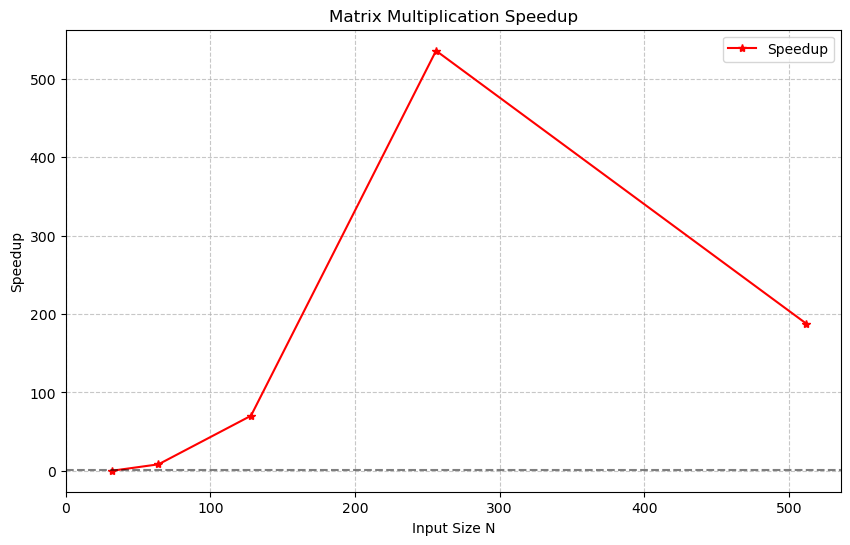

In [23]:
# ================= MATRIX MULT SPEEDUP =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["SPEEDUP"], 'r*-', label='Speedup')
plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
plt.xticks(xticks)
plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Matrix Multiplication Speedup")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

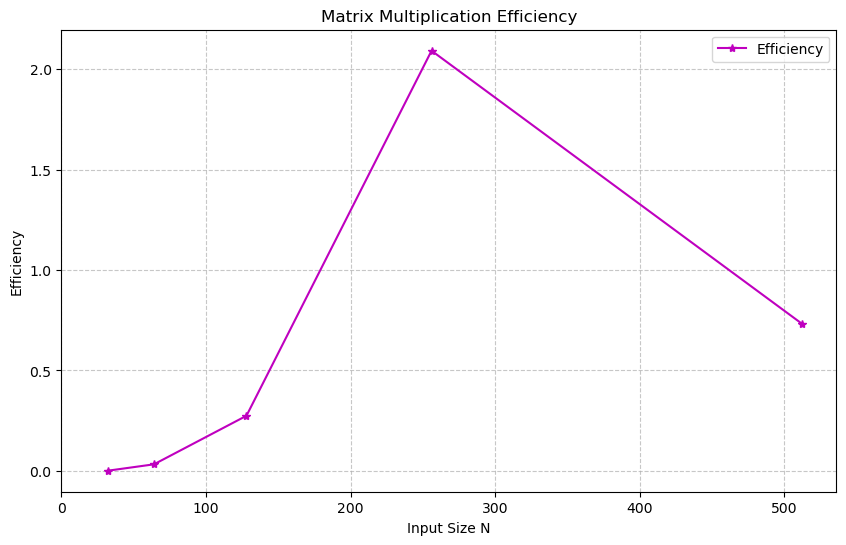

In [24]:
# ================= MATRIX MULT EFFICIENCY =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["EFFICIENCY"], 'm*-', label='Efficiency')
plt.xticks(xticks)
plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Matrix Multiplication Efficiency")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

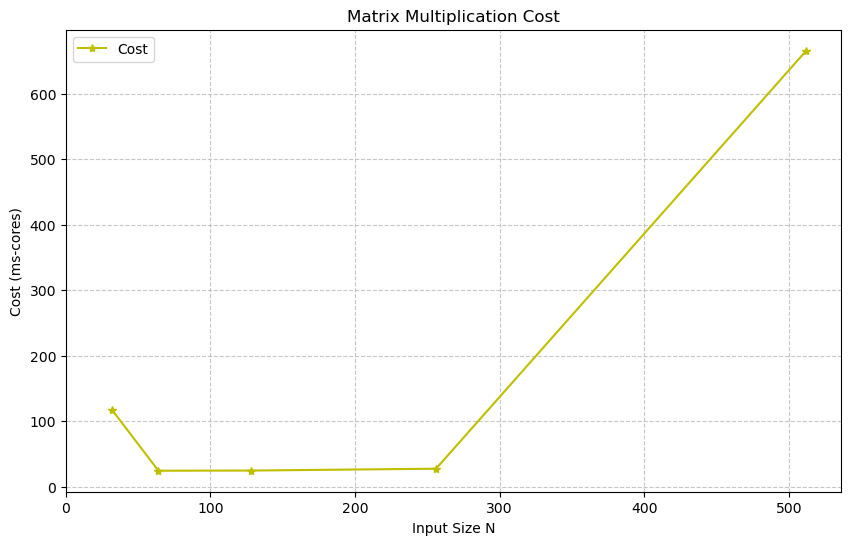

In [25]:
# ================= MATRIX MULT COST =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["COST"], 'y*-', label='Cost')
plt.xticks(xticks)
plt.xlabel("Input Size N")
plt.ylabel("Cost (ms-cores)")
plt.title("Matrix Multiplication Cost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()